In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Vorverarbeitete Daten laden
X_train = pd.read_csv('../data/X_train.csv')
sex_train = pd.read_csv('../data/sex_train.csv').squeeze()

print("Daten geladen.")
print("X_train:", X_train.shape)

Daten geladen.
X_train: (26048, 102)


In [3]:
# Cramér's V Funktion definieren
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

# Cramér's V für alle Features gegenüber Geschlecht berechnen
results = {}
for col in X_train.columns:
    try:
        v = cramers_v(X_train[col], sex_train)
        results[col] = round(v, 4)
    except:
        results[col] = None

# Nach Stärke sortieren
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['cramers_v'])
results_df = results_df.dropna().sort_values('cramers_v', ascending=False)

print(results_df.head(15))


                                   cramers_v
relationship_Husband                  0.5805
marital.status_Married-civ-spouse     0.4335
relationship_Wife                     0.3181
relationship_Unmarried                0.3179
hours.per.week                        0.2790
occupation_Adm-clerical               0.2672
occupation_Craft-repair               0.2262
marital.status_Divorced               0.2259
marital.status_Widowed                0.1889
marital.status_Never-married          0.1764
relationship_Not-in-family            0.1693
occupation_Other-service              0.1481
age                                   0.1405
capital.gain                          0.1405
occupation_Transport-moving           0.1302


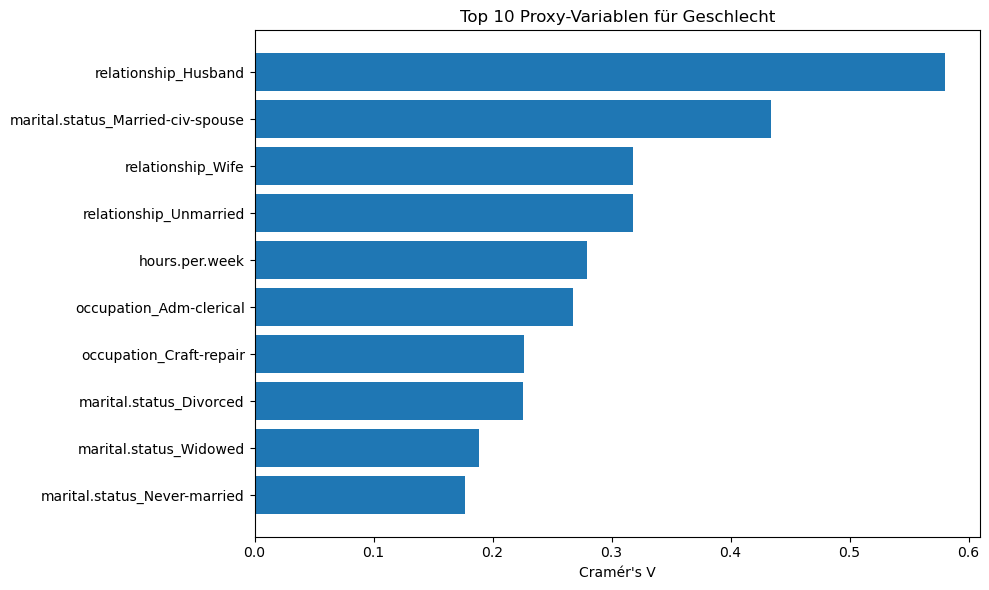

Gespeichert.


In [5]:
# Ergebnisse speichern
results_df.to_csv('../results/tables/cramers_v_results.csv')

# Visualisierung Top 10
top10 = results_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10.index[::-1], top10['cramers_v'][::-1])
plt.xlabel("Cramér's V")
plt.title("Top 10 Proxy-Variablen für Geschlecht")
plt.tight_layout()
plt.savefig('../results/figures/cramers_v_top10.png', dpi=150)
plt.show()
print("Gespeichert.")